# Patrones de Puntos

El análisis de patrones de puntos se basa en la interpretación espacial de eventos localizados. Existen dos formas principales de entender estos puntos:

1. **Puntos como ubicaciones fijas:** En este enfoque, los puntos representan lugares donde se registra una medición y su posición es considerada exógena. El interés se centra en el valor medido, no en la ubicación. Por ejemplo, contar autos en una intersección fija.

2. **Puntos como expresiones de un proceso geográfico:** Aquí, tanto la ubicación como el valor medido son importantes. Los puntos reflejan un proceso continuo subyacente. Por ejemplo, medir alas de aves en distintos lugares permite inferir patrones ecológicos relacionados con su distribución y comportamiento.

Cuando los puntos representan eventos que pueden ocurrir en múltiples ubicaciones pero solo se observan en algunas, hablamos de un **patrón de puntos**. Este patrón puede ser:

- **No marcado:** Solo se conoce la ubicación del evento (por ejemplo, dónde se tomó una foto).
- **Marcado:** Se dispone de información adicional asociada al punto, como hora, tipo de dispositivo, o calidad de la imagen.

Estos patrones permiten estudiar la distribución espacial de los eventos y analizar su concentración, dispersión o relación con otros factores geográficos o contextuales.


## Introducción al Análisis de Patrones de Puntos

El análisis de patrones de puntos se enfoca en visualizar, describir, caracterizar estadísticamente y modelizar la distribución espacial de eventos puntuales. Su objetivo es comprender el proceso generador que da origen a los datos observados. Entre las preguntas centrales que busca responder este enfoque se encuentran:

- ¿Cómo se ve el patrón espacial?
- ¿Cómo se distribuyen los puntos en el espacio?
- ¿Existe alguna estructura en la forma en que se disponen las ubicaciones? ¿Hay concentración (agrupamiento) o dispersión?
- ¿Por qué los eventos ocurren en ciertos lugares y no en otros?

Es fundamental diferenciar entre **proceso** y **patrón**. El **proceso** hace referencia al mecanismo subyacente —no observable directamente— que genera los eventos. Por otro lado, el **patrón** es el resultado visible de dicho proceso. Aunque el patrón es lo que efectivamente observamos, el verdadero desafío analítico es **inferir el proceso** a partir de él.

En este capítulo, se introduce el análisis de patrones de puntos utilizando como ejemplo delitos contra personas, propiedad y seguridad pública en Quito-Ecuador en el periodo 2013-2016. Estas datos son tratados como eventos espaciales: en teoría podrían haberse dado en cualquier lugar, pero en la práctica se concentran en ciertas ubicaciones. Esta perspectiva permite estudiar cómo se agrupan o dispersan los puntos y revelar estructuras espaciales significativas.

Gracias a las herramientas del análisis espacial, es posible transformar una lista de coordenadas aparentemente caótica en una representación inteligible del comportamiento colectivo, permitiendo responder preguntas clave sobre centros de interés, dispersión y concentración de actividades en el espacio urbano.

## Nuevas Formas de Datos y su Aplicación al Estudio Urbano

El acceso a bases de datos georreferenciadas sobre delitos representa una valiosa oportunidad para analizar el comportamiento espacial de la criminalidad en las ciudades. Preguntas como: ¿dónde ocurren los delitos con mayor frecuencia?, ¿en qué momentos del año o del día son más comunes?, ¿por qué ciertos sectores concentran más incidentes que otros?, dejan de ser cuestiones abstractas cuando se dispone de registros espaciales detallados.

En este capítulo se analiza un conjunto de datos sobre delitos contra las personas, la propiedad y la seguridad pública ocurridos en **Quito, Ecuador, durante el periodo 2013–2016**. Estos datos permiten estudiar los patrones espaciales de la delincuencia y comprender cómo varía su distribución a lo largo del territorio urbano.

A partir de este ejemplo, se presentan herramientas y enfoques que permiten explorar y describir la distribución espacial de eventos delictivos, facilitando la identificación de zonas críticas, la evaluación de dispersiones o agrupamientos, y la formulación de hipótesis sobre los procesos sociales y urbanos que subyacen a estos patrones.




In [1]:
uu = "https://raw.githubusercontent.com/vmoprojs/DataLectures/refs/heads/master/SpatialData/REQ_BASE_2013_2016.csv"

import pandas as pd

datos = pd.read_csv(uu,sep = ";")


datos.TIPO_DELITO.value_counts()

tipos = ["CONTRA LA PROPIEDAD","CONTRA LAS PERSONAS","CONTRA LA SEGURIDAD PUBLICA"]

datos_clean = datos[datos["TIPO_DELITO"].isin(tipos)]
datos_clean.TIPO_DELITO.value_counts()


datos_clean = datos_clean[datos_clean["cod_canton"]=="1701"]

datos_clean = datos_clean.rename(columns= {
    'EJE_X': 'longitude', 'EJE_Y': 'latitude'
    })

# Bounding box de Quito (aproximada)
bbox_quito = (-78.6, -0.4, -78.3, 0.05)

datos_clean = datos_clean[
    (datos_clean['longitude'] >= bbox_quito[0]) & 
    (datos_clean['longitude'] <= bbox_quito[2]) & 
    (datos_clean['latitude'] >= bbox_quito[1]) & 
    (datos_clean['latitude'] <= bbox_quito[3]) 
    
    ]

/var/folders/3s/mwy450px7bz09c4zp_hpgl480000gn/T/ipykernel_14100/2426537885.py:5: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  datos = pd.read_csv(uu,sep = ";")


In [2]:
import numpy as np
import geopandas as gpd
import libpysal  as lps # pysal se dividio en submodulos especializados (libpysal, esda, mapclassify)
import seaborn as sns
import contextily as ctx
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN 
from shapely.geometry import Point
from pointpats import centrography

In [3]:
#
db = datos_clean
del datos, datos_clean

La tabla utilizada contiene información detallada sobre una muestra de 10878 registros de delitos. Cada fila corresponde a un delito individual y presenta las siguientes variables:

- **TIPO_DELITO**: Identificador de delito 'CONTRA LAS PERSONAS', 'CONTRA LA PROPIEDAD', 'CONTRA LA SEGURIDAD PUBLICA'.
- **SUBTIPO_DE_DELITO**: Categoría más específica del delito.
- **FECHA_DETENCION**: Fecha y hora exacta en la que fue la detención.
- **Coordenadas proyectadas (x,y)**: Versión transformada de la ubicación en el sistema de referencia Pseudo-Mercator, útil para análisis espaciales precisos.
- **Coordenadas (longitude,latitude)**: Versión transformada de la ubicación en el sistema de referencia Pseudo-Mercator, útil para análisis espaciales precisos.

Esta estructura de datos permite analizar tanto el comportamiento espacial como temporal de la actividad registrada, facilitando la identificación de patrones en el uso del espacio urbano.


In [4]:
db.info()

# 1. Crear geometría en EPSG:4326
gdf = gpd.GeoDataFrame(
    db.copy(),
    geometry=[Point(xy) for xy in zip(db['longitude'], db['latitude'])],
    crs="EPSG:4326"
)

# 2. Transformar a EPSG:3857
gdf_3857 = gdf.to_crs(epsg=3857)

# 3. Extraer coordenadas transformadas y agregarlas al DataFrame original
db['x'] = gdf_3857.geometry.x
db['y'] = gdf_3857.geometry.y

<class 'pandas.core.frame.DataFrame'>
Index: 10878 entries, 75 to 73244
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TIPO_DELITO              10878 non-null  object 
 1   SUBTIPO_DE_DELITO        10878 non-null  object 
 2   FECHA_DETENCION          10878 non-null  object 
 3   NUMERO_DE_DETENCIONES    9783 non-null   float64
 4   ZONA                     10878 non-null  object 
 5   PROVINCIA                10878 non-null  object 
 6   cod_provincia            10878 non-null  object 
 7   CANTON                   10878 non-null  object 
 8   cod_canton               10878 non-null  object 
 9   PARROQUIA                10878 non-null  object 
 10  cod_parroquia            10878 non-null  object 
 11  DISTRITO                 10878 non-null  object 
 12  cod_distrito             10878 non-null  object 
 13  CIRCUITO                 10878 non-null  object 
 14  cod_circuito             1

### Visualización de Patrones de Puntos

Existen múltiples formas de visualizar patrones espaciales de puntos, y la elección del método depende del mensaje que se desea comunicar.

#### Representación básica con puntos en un mapa

El primer paso para explorar la dimensión espacial de un conjunto de datos es representarlo gráficamente. Una forma sencilla de hacerlo es mediante un **diagrama de dispersión (scatterplot)**, que permite observar cómo se distribuyen los eventos en el espacio.

Este tipo de visualización consiste en graficar las coordenadas geográficas (por ejemplo, latitud y longitud) como puntos individuales sobre un mapa o plano de referencia. A pesar de su simplicidad, esta técnica es útil para identificar concentraciones, vacíos, o patrones iniciales de agrupamiento.

En la siguiente Figura, se muestra un ejemplo de este tipo de visualización utilizando la biblioteca `seaborn`, una herramienta común en el análisis de datos geoespaciales con Python.


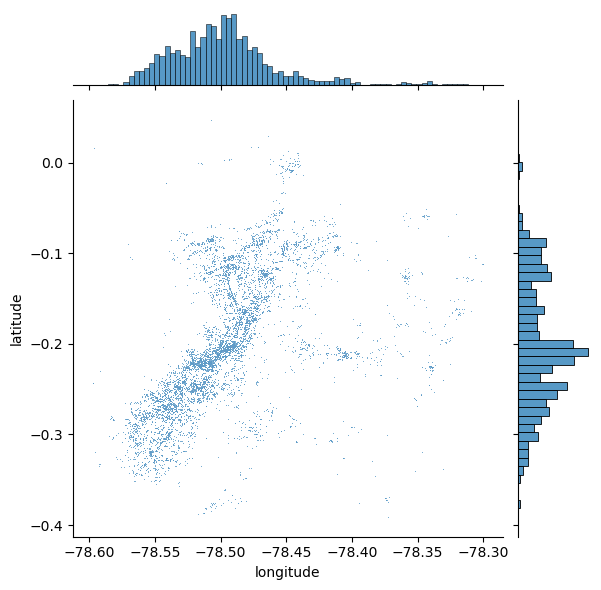

In [5]:
sns.jointplot(x="longitude", y="latitude", data=db, s=0.5);

## Añadiendo Contexto a la Visualización

El diagrama de dispersión inicial ofrece un buen punto de partida: permite observar que los puntos tienden a concentrarse hacia el centro del área cubierta, siguiendo un patrón no aleatorio. Además, dentro de ese patrón general, se pueden distinguir agrupamientos más localizados.

No obstante, esta visualización presenta dos limitaciones importantes:

1. **Falta de contexto geográfico**: no hay referencia visual del entorno urbano en el que ocurren los eventos.
2. **Alta densidad de puntos**: en zonas con mucha concentración, los puntos se superponen tanto que resulta difícil distinguir detalles o interpretar patrones con claridad.

### Incorporando un mapa base

Para superar estas limitaciones, el primer paso es proporcionar **contexto geográfico**. Una manera sencilla y eficaz de hacerlo es **superponer un mapa base** (tile map) proveniente de servicios en línea. Esto permite visualizar los puntos dentro del entorno urbano real, facilitando la interpretación espacial.

En este caso, se utiliza la biblioteca `contextily`, que permite integrar mapas base fácilmente en gráficos de datos geográficos. Combinándola con `jointplot`, se genera la siguiente Figura, en la que los puntos se ubican sobre un fondo de mapa urbano, mejorando significativamente la legibilidad y comprensión de los patrones espaciales.


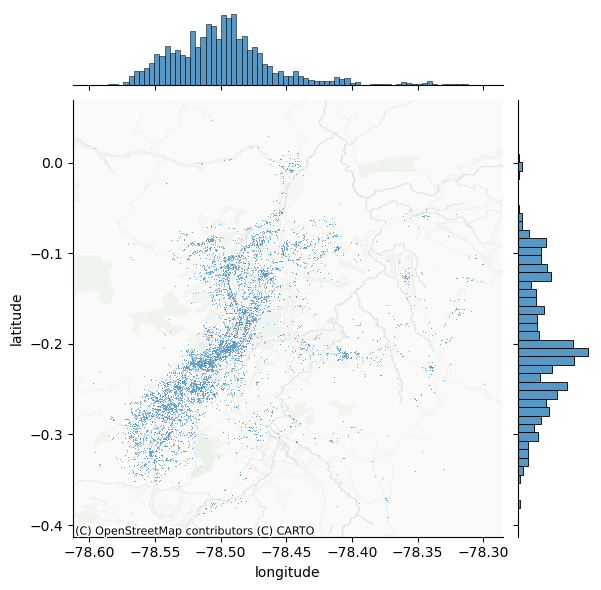

In [6]:

# Generate scatter plot
joint_axes = sns.jointplot(
    x="longitude", y="latitude", data=db, s=0.5
)
ctx.add_basemap(
    joint_axes.ax_joint,
    crs="EPSG:4326",
    source=ctx.providers.CartoDB.PositronNoLabels,
);


Una mejora clave en la visualización consiste en **extraer el eje donde se grafican los puntos** y superponer allí un **mapa base**. Para ello, es importante especificar correctamente el sistema de referencia de coordenadas (CRS), en este caso **WGS84**, ya que se están utilizando coordenadas de latitud y longitud.

### Ventajas de incluir un mapa base

Comparado con el gráfico anterior, la adición de un fondo cartográfico mejora notablemente la interpretación espacial del patrón. En el caso original con datos de **delitos**, el uso del mapa permite:

- Entender mejor la relación entre la distribución de puntos y el entorno urbano.
- Visualizar con mayor precisión las zonas de alta concentración.
- Identificar calles, plazas o barrios específicos que coinciden con los agrupamientos observados.

Este principio se puede aplicar igualmente a otros tipos de datos espaciales, como la localización de delitos en una ciudad, permitiendo analizar cómo se relacionan los eventos con el espacio construido y los elementos del entorno.


## Representar la Densidad con Hexbinning

Un desafío común al visualizar grandes volúmenes de puntos geográficos es el **exceso de superposición**. Cuando muchos eventos se concentran en una misma área, como sucede con los delitos en ciertos sectores de la ciudad, el uso de puntos opacos uno sobre otro dificulta discernir patrones. Por ejemplo, en la siguiente Figura (al centro-izquierda del mapa), se observa una aparente gran concentración de delitos, pero no es posible determinar visualmente si toda esa zona tiene la misma intensidad o si existen focos específicos con mayor actividad.

### Solución: de puntos individuales a superficies

Una manera efectiva de abordar este problema consiste en transformar la visualización de puntos en una **superficie de densidad**, lo que equivale a construir un **histograma espacial bidimensional**. El procedimiento consiste en:

- Dividir el espacio en una cuadrícula regular (de celdas cuadradas o hexagonales).
- Contar cuántos eventos caen dentro de cada celda.
- Representar los conteos mediante colores, al estilo de un mapa coroplético.

Este enfoque es intuitivo, fácil de interpretar y elimina algunas distorsiones asociadas a otros métodos, especialmente cuando se usa una malla **hexagonal** (hexbin), la cual ofrece ventajas como una conectividad más uniforme entre celdas y menor distorsión visual que las cuadrículas cuadradas.

La creación de este tipo de visualización es sencilla en Python utilizando la función `hexbin`, y permite identificar rápidamente zonas de alta y baja concentración de eventos dentro del área de estudio.


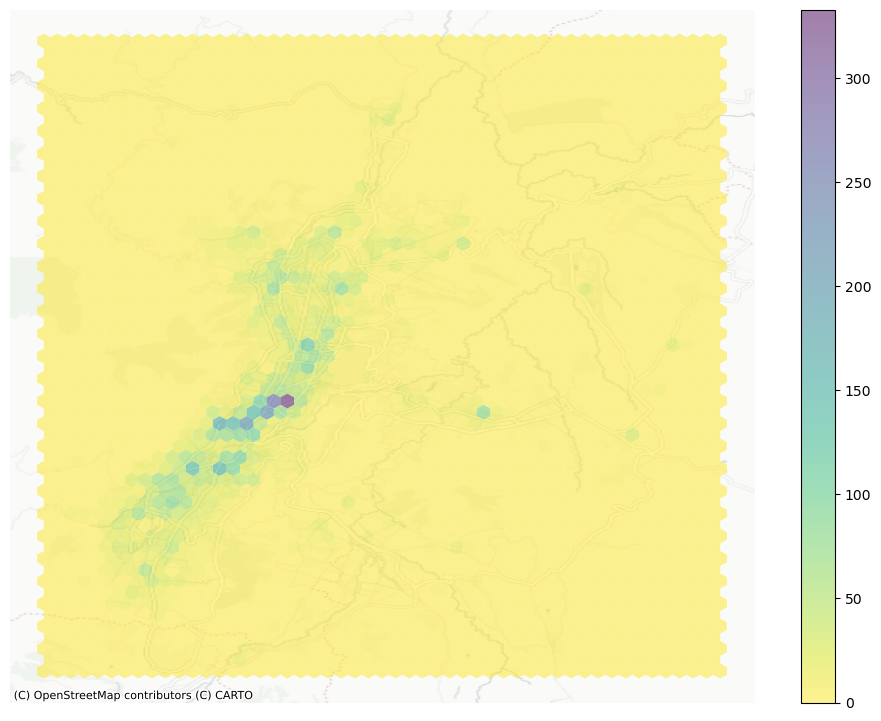

In [7]:
# Set up figure and axis
f, ax = plt.subplots(1, figsize=(12, 9))
# Generate and add hexbin with 50 hexagons in each
# dimension, no borderlines, half transparency,
# and the reverse viridis colormap
hb = ax.hexbin(
    db["x"],
    db["y"],
    gridsize=50,
    linewidths=0,
    alpha=0.5,
    cmap="viridis_r",
)
# Add basemap
ctx.add_basemap(
    ax, 
    #crs="EPSG:4326",
    source=ctx.providers.CartoDB.PositronNoLabels
)
# Add colorbar
plt.colorbar(hb)
# Remove axes
ax.set_axis_off()

## Otro Tipo de Densidad: Estimación de Densidad por Kernel (KDE)

El uso de cuadrículas regulares, como vimos con el **hexbinning**, es el equivalente espacial de un histograma: el usuario define el número de “celdas” o “recipientes” y se contabilizan cuántos eventos caen dentro de cada uno. Este método es rápido, eficiente y puede ofrecer mucho detalle si se usan suficientes divisiones. Sin embargo, implica una **discretización** de un fenómeno que, en esencia, es **continuo**, lo cual puede introducir distorsiones —como las derivadas del problema de la unidad espacial modificable (MAUP).

### Alternativa: Estimación de Densidad por Kernel (KDE)

Una alternativa más flexible es la **estimación de densidad por kernel (KDE)**, que permite aproximar empíricamente una función de densidad de probabilidad. En lugar de usar celdas rígidas, la KDE coloca una malla de puntos sobre el espacio de análisis y aplica una **función kernel** sobre cada uno. Esta función asigna pesos a los eventos cercanos según la distancia: los eventos más cercanos contribuyen más, y los lejanos, menos.

El resultado final es una **superficie continua** que representa la densidad estimada de eventos en cada punto del espacio.

- La función kernel más común es la **gaussiana**, que aplica una distribución normal como peso.
- Esta superficie puede interpretarse como una **probabilidad suavizada de ocurrencia** de eventos, evaluable en cualquier lugar del área de estudio.

En Python, crear un mapa de densidad con kernel gaussiano es bastante sencillo utilizando la función `seaborn.kdeplot()`, como se muestra en la siguiente Figura. Esta técnica es especialmente útil para identificar **zonas calientes** (hotspots) y visualizar la concentración de fenómenos de forma continua y precisa.


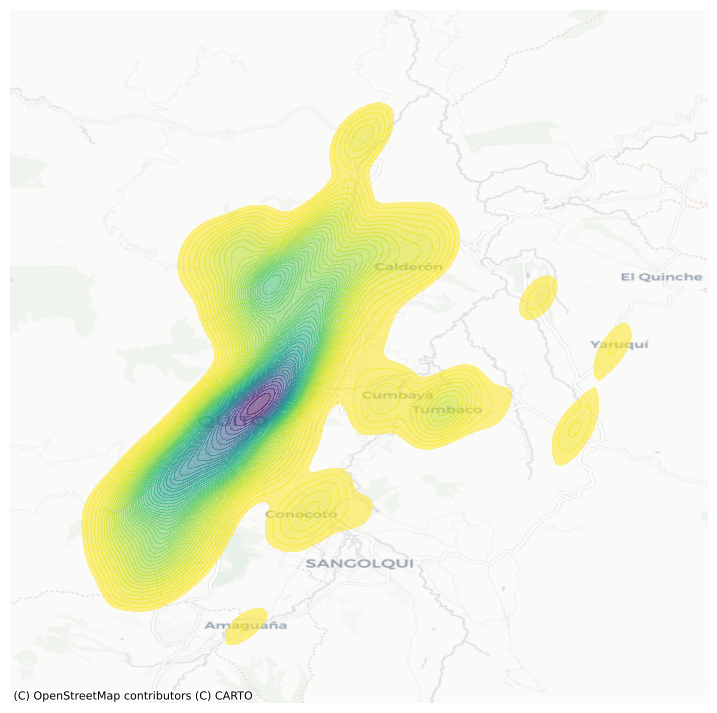

In [8]:
# Set up figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Generate and add KDE with a shading of 50 gradients
# coloured contours, 75% of transparency,
# and the reverse viridis colormap
sns.kdeplot(
    x="x",
    y="y",
    data=db,
    n_levels=50,
    fill=True,
    alpha=0.55,
    cmap="viridis_r",
)
# Add basemap
ctx.add_basemap(
    ax,
    #crs="EPSG:4326", 
    source=ctx.providers.CartoDB.Positron
)
# Remove axes
ax.set_axis_off()


El resultado de aplicar una estimación de densidad por kernel (**KDE**) es una superficie **más suave y continua**, que conserva la estructura general observada en el hexbin, pero con **transiciones más graduales** entre áreas de distinta intensidad. Esta suavidad permite una **mejor generalización** de la distribución teórica de los eventos en el espacio.

### Interpretación técnica y utilidad

Desde el punto de vista técnico, la naturaleza continua de la función KDE implica que la **probabilidad exacta de un evento en un punto específico es cero**, ya que se trata de una función de densidad, no de una probabilidad puntual. Sin embargo, al considerar un área alrededor de ese punto, sí se puede calcular la **probabilidad de que un evento ocurra dentro de esa región**.

Esto hace que la KDE sea especialmente útil en dos sentidos:

- Permite **escapar de las limitaciones impuestas por las cuadrículas regulares** (cuadradas o hexagonales).
- Ofrece una representación **más realista de fenómenos espaciales continuos**, como la concentración de delitos, la movilidad urbana o la propagación de enfermedades.

En resumen, la KDE entrega una visualización más fluida y analíticamente potente para fenómenos que no se distribuyen de forma estrictamente discreta, facilitando la identificación de patrones espaciales relevantes.


## Centrografía: Medidas de Centralidad Espacial

La **centrografía** es el estudio de la **centralidad** en un patrón de puntos. Este concepto se refiere tanto a la **ubicación general** como a la **dispersión** del conjunto de eventos en el espacio. Así como el hexbin puede interpretarse como un “histograma espacial”, la centrografía cumple una función similar a las medidas de **tendencia central** (como la media o la mediana) en estadística tradicional.

### ¿Para qué sirve la centrografía?

Las medidas centrográficas permiten **resumir distribuciones espaciales** de manera compacta, por ejemplo, mediante un único punto que representa el “centro” de la concentración de eventos.

Estas medidas son útiles para:

- Determinar **dónde** se localiza el centro espacial de un fenómeno.
- Evaluar **cuán dispersos** están los eventos en torno a ese centro.
- Identificar si la **forma del patrón** es regular, alargada o irregular.

### Aplicaciones

En el contexto del análisis urbano, como el estudio de delitos en una ciudad, la centrografía permite:

- Detectar **cambios en la localización de hotspots** delictivos a lo largo del tiempo.
- Comparar la concentración espacial de distintos tipos de delitos.
- Estudiar la evolución del **desplazamiento del centro de gravedad** del crimen en relación con variables urbanas, sociales o económicas.

En resumen, la centrografía ofrece herramientas cuantitativas para describir y comparar la estructura espacial de fenómenos distribuidos en forma de puntos.


### Tendencia Central: Medidas de Ubicación en un Patrón de Puntos

Una de las medidas más comunes de tendencia central en un patrón de puntos es el **centro de masa**. Este punto representa el centro geométrico del patrón, y su cálculo depende de si el patrón está **marcado** (con atributos adicionales) o **no marcado**.

**Centro de masa y media espacial**

- En **patrones no marcados**, el centro de masa equivale al **centro medio**, es decir, el promedio de las coordenadas de todos los puntos. Es una medida sencilla que resume la ubicación general del fenómeno.
- En **patrones marcados**, el centro de masa toma en cuenta los valores de la marca (por ejemplo, intensidad, severidad, frecuencia), lo que desplaza el centro hacia las observaciones con valores más altos.

**Centro mediano**

Otra medida relevante es el **centro mediano**, que es análogo a la mediana tradicional. Se define como el punto que divide el conjunto de eventos de manera que:

- La mitad se ubica **a la derecha** y la otra mitad **a la izquierda**, y
- La mitad se ubica **por encima** y la otra **por debajo**.

Este tipo de centro es más **robusto ante valores extremos** o distribuciones irregulares.

**Aplicación práctica**

En Python, se puede analizar el **centro medio** de un patrón de puntos utilizando el paquete `pointpats`, que facilita el cálculo de diversas medidas centrográficas.

Estas métricas permiten entender no solo **dónde** se concentran los eventos (como delitos, por ejemplo), sino también cómo se **desplaza o cambia el centro** del fenómeno a lo largo del tiempo o entre distintas categorías.


In [9]:
mean_center = centrography.mean_center(db[["x", "y"]])
med_center = centrography.euclidean_median(db[["x", "y"]])

La forma más clara de interpretar el **centro medio** de un patrón de puntos es **visualizarlo en conjunto con los propios eventos**, superponiéndolos en un mismo gráfico. Esta representación permite observar de forma intuitiva cómo se relaciona la ubicación promedio con la distribución general del fenómeno.

**Ejemplo gráfico**

En la siguienten Figura se ilustra esta idea mostrando:

- El **patrón de puntos** completo (por ejemplo, ubicaciones de delitos).
- El **centro medio**, marcado como un punto distinto (generalmente en color y forma contrastantes).

Esta comparación gráfica facilita:

- Evaluar si el centro refleja bien la distribución del conjunto.
- Detectar si existen **asimetrías** o **agrupamientos** que alejan el centro de lo que visualmente parecería más representativo.
- Comparar centros medios de distintos períodos o categorías de eventos.

Este tipo de análisis visual es particularmente útil en contextos urbanos, como el estudio de delitos en Quito, donde el desplazamiento del centro puede estar asociado a dinámicas socioespaciales relevantes.


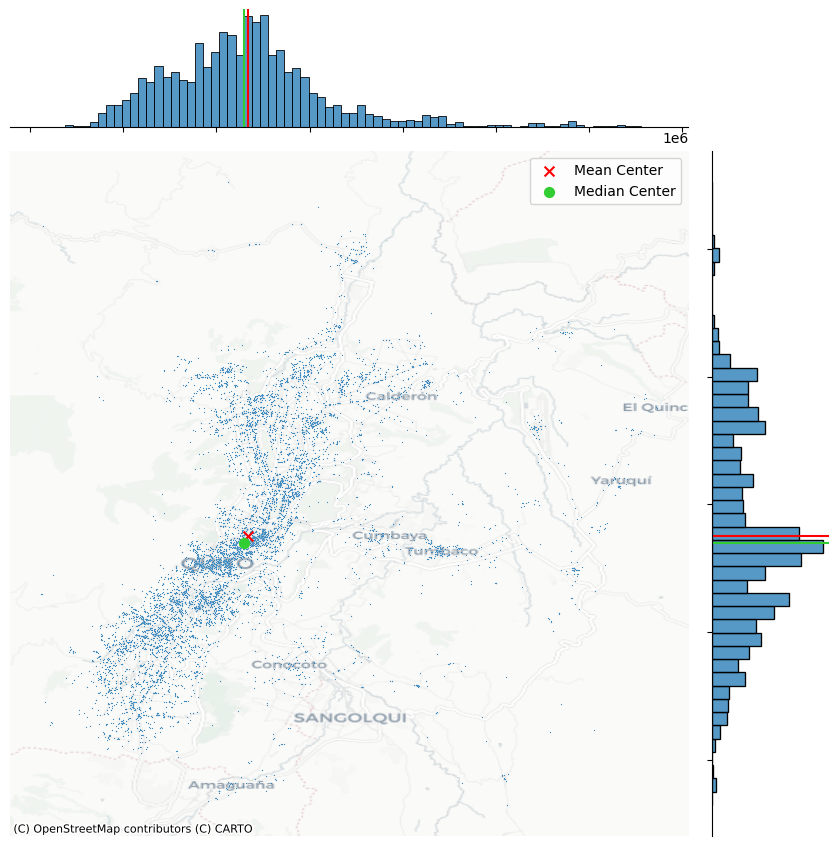

In [10]:
# Generate scatterplot
joint_axes = sns.jointplot(
    x="x", y="y", data=db, s=0.75, height=9
)
# Add mean point and marginal lines
joint_axes.ax_joint.scatter(
    *mean_center, color="red", marker="x", s=50, label="Mean Center"
)
joint_axes.ax_marg_x.axvline(mean_center[0], color="red")
joint_axes.ax_marg_y.axhline(mean_center[1], color="red")
# Add median point and marginal lines
joint_axes.ax_joint.scatter(
    *med_center,
    color="limegreen",
    marker="o",
    s=50,
    label="Median Center"
)
joint_axes.ax_marg_x.axvline(med_center[0], color="limegreen")
joint_axes.ax_marg_y.axhline(med_center[1], color="limegreen")
# Legend
joint_axes.ax_joint.legend()
# Add basemap
ctx.add_basemap(
    joint_axes.ax_joint,
    # crs="EPSG:4326", 
    source=ctx.providers.CartoDB.Positron
)
# Clean axes
joint_axes.ax_joint.set_axis_off()
# Display
plt.show()


La **diferencia entre el centro medio y el centro mediano** refleja la **asimetría** en la distribución espacial del patrón de puntos. En el ejemplo original de los delitos enm Quito:

- Existen varios **grupos dispersos de delitos** en el oeste y sur de la ciudad.
- En contraste, el norte y este están **densamente poblados de puntos**, pero su extensión es más limitada.

Esta **distribución asimétrica** genera un sesgo:

- El **centro medio** se ve **arrastrado hacia las zonas más alejadas** (oeste y sur), debido a la influencia de los puntos extremos.
- El **centro mediano**, al depender de la posición relativa de los puntos y no de sus valores extremos, **permanece más cercano al núcleo denso** de la distribución.


Este fenómeno es relevante porque:

- El centro medio puede **sobreestimar el desplazamiento espacial** cuando hay valores atípicos o zonas remotas con poca densidad.
- El centro mediano ofrece una **medida más robusta y resistente al sesgo** generado por puntos extremos.

En el análisis de fenómenos como la criminalidad urbana, esta diferencia puede ayudar a distinguir entre una **distribución efectivamente dispersa** y una que contiene **agrupamientos puntuales atípicos**, con implicaciones importantes para la toma de decisiones en políticas públicas o despliegue de recursos.


### Dispersión: Medida de Extensión Espacial

Una medida clásica de **dispersión espacial** en centrografía es la **distancia estándar**. Esta métrica cuantifica el **promedio de las distancias de todos los puntos respecto al centro del patrón**, típicamente el **centro de masa** (centro medio).

**¿Qué nos dice la distancia estándar?**

- Permite estimar **qué tan dispersos** están los eventos alrededor del centro.
- Cuanto mayor sea esta distancia, **más extendido** es el patrón de puntos en el espacio.
- Una distancia baja sugiere una **alta concentración** o agrupamiento en torno al centro.

**Cálculo en Python**

La distancia estándar se puede calcular fácilmente con el paquete `pointpats`, utilizando la función `std_distance()`, que automatiza el proceso:

1. Se calcula el centro medio del conjunto de puntos.
2. Se obtiene la distancia de cada punto a ese centro.
3. Se promedia dicha distancia para obtener la medida global de dispersión.

**Aplicación**

En contextos como el análisis delictivo en ciudades:

- Esta métrica ayuda a entender **la extensión geográfica del fenómeno**.
- Comparar la distancia estándar entre distintos años o tipos de delito permite observar **cambios en la distribución espacial**.
- También puede apoyar decisiones sobre **cobertura territorial** de intervenciones o vigilancia.

En resumen, la distancia estándar resume en un solo valor cuán amplio o concentrado es un patrón de eventos en el territorio.


In [11]:
centrography.std_distance(db[["x", "y"]])

np.float64(9160.760525257383)

En el caso de nuestro ejemplo, una distancia estándar de aproximadamente **8.800 metros** indica que, en promedio, los delitos se dieron a esa distancia del **centro medio**. Este valor proporciona una idea general del **radio de dispersión** de los eventos en el espacio.

**Elipse de desviación estándar**

Una herramienta visual complementaria y muy útil en centrografía es la **elipse de desviación estándar** (o **elipse estándar**). Esta elipse se construye a partir de los datos espaciales y refleja:

- El **centro** del patrón.
- La **dispersión** en dos direcciones principales (ejes mayor y menor).
- La **orientación** espacial predominante del conjunto de puntos.

**¿Qué muestra esta elipse?**

- La **forma** de la elipse indica si el patrón es más **alargado** o **circular**.
- Su **inclinación** sugiere la dirección principal en la que se distribuyen los eventos.
- Su **tamaño** se relaciona con la magnitud de la dispersión en cada eje.

**Cálculo en Python**

Para crear esta elipse en Python, se puede usar la función `ellipse()` del paquete `pointpats`, que calcula automáticamente:

- La longitud de los ejes mayor y menor.
- El ángulo de rotación de la elipse respecto al eje horizontal.
- La ubicación del centro.

Esta visualización es especialmente valiosa en análisis urbanos (como el estudio de delitos), ya que permite observar **tendencias espaciales predominantes**, **zonas de elongación** del fenómeno y **posibles desplazamientos** en su orientación a lo largo del tiempo.


In [12]:
major, minor, rotation = centrography.ellipse(db[["x", "y"]])

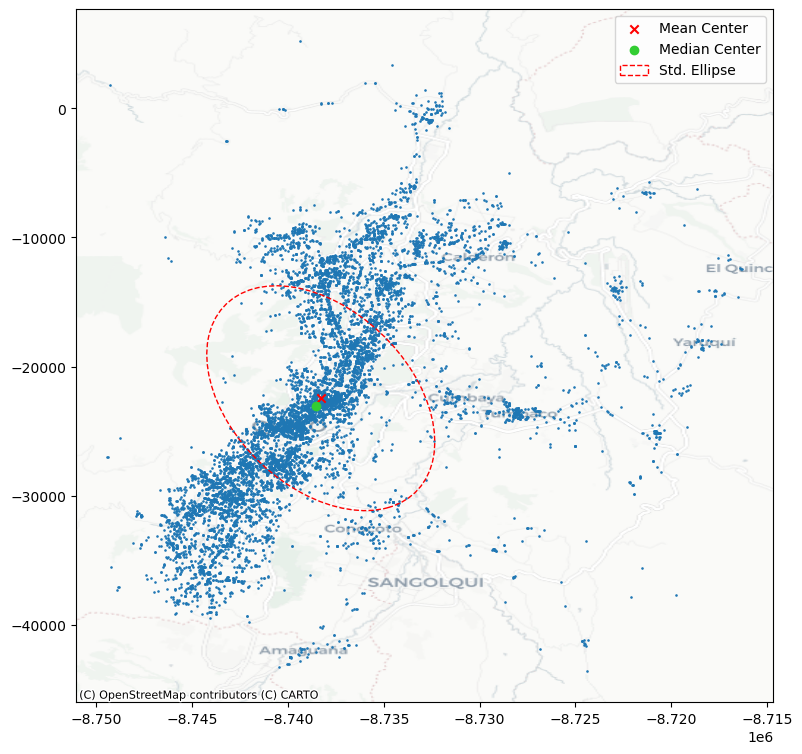

In [13]:
from matplotlib.patches import Ellipse

# Set up figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot photograph points
ax.scatter(db["x"], db["y"], s=0.75)
ax.scatter(*mean_center, color="red", marker="x", label="Mean Center")
ax.scatter(
    *med_center, color="limegreen", marker="o", label="Median Center"
)

# Construct the standard ellipse using matplotlib
ellipse = Ellipse(
    xy=mean_center,  # center the ellipse on our mean center
    width=major * 2,  # centrography.ellipse only gives half the axis
    height=minor * 2,
    angle=np.rad2deg(
        rotation
    ),  # Angles for this are in degrees, not radians
    facecolor="none",
    edgecolor="red",
    linestyle="--",
    label="Std. Ellipse",
)
ax.add_patch(ellipse)

ax.legend()
# Display
# Add basemap
ctx.add_basemap(
    ax, 
    # crs="EPSG:4326", 
    source=ctx.providers.CartoDB.Positron
)
plt.show()

### Extensión: Medidas de Cobertura Espacial en Centrografía

La última categoría de medidas centrográficas que exploraremos se enfoca en la **extensión** del patrón de puntos, es decir, en **cuánto espacio ocupa** el conjunto de eventos. Para ello, se utilizan distintas formas geométricas que permiten representar, con distintos grados de ajuste, la **envolvente** del patrón.

**Cuatro formas comunes para medir la extensión**

Estas formas varían en **qué tan estrictamente delimitan** el patrón de puntos:

1. **Rectángulo delimitador (Bounding Box):** la envolvente más simple, alineada a los ejes.
2. **Convex Hull (Casco convexo):** la forma convexa más ajustada que contiene todos los puntos.
3. **Minimum Bounding Circle:** el círculo más pequeño que encierra todos los eventos.
4. **Alpha Shape (o envolvente cóncava):** una forma más flexible que puede capturar huecos o concavidades del patrón.

*¿Qué nos dicen estas medidas?*

- Ayudan a **cuantificar el tamaño geográfico** del patrón.
- Permiten comparar la **forma y dispersión** entre distintos conjuntos de puntos.
- Son útiles para estudios de **concentración, dispersión o expansión territorial** de fenómenos.

**Ejemplo práctico**

Para ilustrar las diferencias entre estas medidas, se puede aplicar el análisis a un subconjunto específico de datos. Por ejemplo, datos de delitos (cod_parroquia: 170184), se puede visualizar cómo varían estas formas al aplicarse al mismo grupo de puntos.

Este tipo de visualización comparativa revela:

- Qué tan **compacto o disperso** es un subconjunto del fenómeno.
- Qué medidas de extensión son más representativas según la morfología del patrón.
- Qué forma es más adecuada dependiendo del objetivo analítico (resumen, modelación, delimitación, etc.).

En el análisis de datos urbanos como delitos, estas medidas permiten evaluar la **expansión geográfica de la criminalidad** en ciertos grupos poblacionales, zonas o períodos específicos.


In [14]:
user = db.query('cod_parroquia == "170184"')
coordinates = user[["x", "y"]].values

La primera medida de extensión que aplicaremos es el **casco convexo**, una forma geométrica que **encierra todos los puntos del patrón** mediante la **envolvente convexa más ajustada posible**.

**¿Qué es una forma convexa?**

Una forma convexa se caracteriza por:

- No tener **reentrancias ni huecos**.
- Todos sus ángulos internos son **menores a 180 grados**.
- Una línea recta trazada entre dos puntos dentro de la figura **permanece completamente dentro de ella**.

En términos simples, el casco convexo **no se repliega sobre sí mismo**; es la envolvente exterior más simple que **abarca todos los eventos** del patrón.

**Aplicación práctica**

En nuestro ejemplo con los datos de la parroguia (cod_parroquia: 170184), el casco convexo nos da una **primera aproximación al área total** en la que se distribuyen los delitosconvex_hull_vertices = centrography.hull(coordinates).

- Este método se calcula fácilmente con la función `centrography.hull`.
- El resultado es una **forma poligonal cerrada**, que resume la **extensión total del patrón de puntos** de manera sencilla, aunque puede sobreestimar el área real si hay huecos internos.

### Utilidad en análisis espacial

En contextos como el estudio de delitos:

- El casco convexo permite identificar el **área mínima de intervención o monitoreo**.
- Sirve como base para comparar la **extensión geográfica entre diferentes grupos o momentos**.
- Es útil para detectar si un fenómeno se está **expandiendo o contrayendo** en el espacio urbano.

En resumen, el casco convexo es una herramienta básica pero poderosa para resumir la distribución espacial de un conjunto de eventos.


In [15]:
convex_hull_vertices = centrography.hull(coordinates)


La segunda medida que exploramos es el **alpha shape**, una versión más ajustada y flexible del **casco convexo**.

**¿Qué es un alpha shape?**

Una forma intuitiva de entender el alpha shape es pensar en el siguiente experimento:

- Imagina que **"ruedas una bola alrededor del conjunto de puntos"**.
- Si la bola es **muy grande** (radio infinito), solo rozará los bordes exteriores, formando el **casco convexo**.
- Si la bola es **más pequeña**, podrá **entrar en los huecos y depresiones** del patrón, generando una **envolvente más ajustada**.

A medida que se reduce el valor de **alpha** (el parámetro que regula el tamaño de la bola), la forma se adapta más a los contornos reales del patrón de puntos. Pero si alpha es demasiado pequeño, la bola **puede colarse entre puntos dispersos**, creando **múltiples formas desconectadas**.

**Ventajas del alpha shape**

- Captura mejor la **forma real** del patrón, incluyendo huecos, valles y concavidades.
- Permite distinguir entre patrones **densos y conectados** y otros más **dispersos y fracturados**.
- Es especialmente útil cuando el patrón tiene **estructura interna compleja**.

**Aplicación en Python**

La librería `libpysal` proporciona la función `alpha_shape_auto`, que encuentra automáticamente el **menor alpha** posible que aún genere **una sola forma envolvente**. Esto evita el ensayo y error de tener que ajustar el parámetro manualmente.

**Relevancia en análisis espacial**

Para fenómenos como los delitos en ciudades:

- El alpha shape revela **áreas de verdadera concentración delictiva**, ignorando espacios vacíos dentro del casco convexo.
- Permite una delimitación más precisa de **zonas de intervención prioritaria**.
- Puede detectar la existencia de **subgrupos** de eventos o **patrones de dispersión** desconectados.

En resumen, el alpha shape es una herramienta poderosa para representar la extensión espacial **real** de un fenómeno, más allá de la envoltura convexa básica.


/var/folders/3s/mwy450px7bz09c4zp_hpgl480000gn/T/ipykernel_14100/1932403822.py:1: UserWarning: Numba not imported, so alpha shape construction may be slower than expected.
  alpha_shape, alpha, circs = lps.cg.alpha_shape_auto(


/var/folders/3s/mwy450px7bz09c4zp_hpgl480000gn/T/ipykernel_14100/1932403822.py:60: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend();


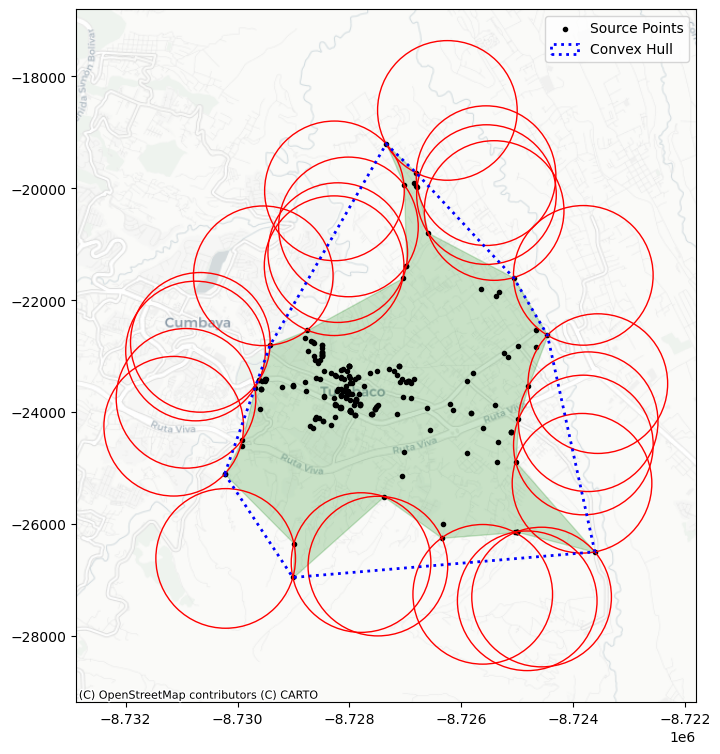

In [16]:
alpha_shape, alpha, circs = lps.cg.alpha_shape_auto(
    coordinates, return_circles=True
)


f, ax = plt.subplots(1, 1, figsize=(9, 9))

# Plot a green alpha shape
gpd.GeoSeries(
    [alpha_shape]
).plot(
    ax=ax,
    edgecolor="green",
    facecolor="green",
    alpha=0.2,
    label="Tightest single alpha shape",
)

# Include the points for our prolific user in black
ax.scatter(
    *coordinates.T, color="k", marker=".", label="Source Points"
)

# plot the circles forming the boundary of the alpha shape
for i, circle in enumerate(circs):
    # only label the first circle of its kind
    if i == 0:
        label = "Bounding Circles"
    else:
        label = None
        ax.add_patch(
            plt.Circle(
                circle,
                radius=alpha,
                facecolor="none",
                edgecolor="r",
                label=label,
            )
        )
        
# add a blue convex hull
ax.add_patch(
    plt.Polygon(
        convex_hull_vertices,
        closed=True,
        edgecolor="blue",
        facecolor="none",
        linestyle=":",
        linewidth=2,
        label="Convex Hull",
    )
)

# Add basemap
ctx.add_basemap(
    ax, 
    # crs="EPSG:4326", 
    source=ctx.providers.CartoDB.Positron
)
plt.legend();

## Aleatoriedad y Agrupamiento Espacial

Más allá de la centralidad y la extensión, un objetivo fundamental en el análisis espacial de patrones de puntos es entender **qué tan uniformemente distribuidos** están los eventos en el espacio. En otras palabras, se busca identificar si los puntos tienden a **agruparse** (clustering) o si están **dispersos** de forma homogénea.

**¿Qué se analiza?**

Este tipo de preguntas se refiere a la **intensidad** o **dispersión global** del patrón. En términos de estadística espacial, se relaciona con conceptos como la **autocorrelación espacial global**, que mide si los eventos tienden a ocurrir cerca unos de otros.

**Objetivo**

El propósito es responder preguntas como:

- ¿Hay evidencia de **agrupamientos significativos**?
- ¿Es el patrón compatible con una distribución aleatoria?
- ¿Dónde se concentran más intensamente los eventos?

### Técnicas para detectar agrupamiento

#### 1. Estadísticos de cuadrantes (Quadrat Statistics)

- Dividen el área de estudio en **pequeñas celdas regulares** (cuadrantes).
- Se cuenta cuántos puntos caen en cada celda.
- Luego se analiza la **uniformidad** de los conteos entre celdas.
- Son útiles para detectar **variaciones espaciales globales**.

#### 2. Funciones de distancia: Métodos derivados de Ripley (1988)

- Se basan en medir las **distancias entre puntos** dentro del patrón.
- Evalúan si los puntos están **más cerca o más lejos entre sí** que lo que se esperaría bajo una distribución aleatoria.
- Métodos como la **función K de Ripley** permiten analizar el **agrupamiento a distintas escalas espaciales**.

### Importancia en análisis urbano

Estas técnicas son fundamentales para estudiar fenómenos como la delincuencia, donde identificar **zonas calientes**, **concentraciones no aleatorias** o **puntos críticos de intervención** puede guiar acciones de política pública más efectivas.

En resumen, los análisis de aleatoriedad y agrupamiento ayudan a distinguir entre una distribución espacial **estructurada** (por ejemplo, vinculada a factores urbanos o sociales) y una distribución **aleatoria**.


In [17]:
from pointpats import (
    distance_statistics,
    QStatistic,
    random,
    PointPattern,
)

## Simulación de Aleatoriedad Espacial: Proceso de Poisson

Para entender mejor cómo se comporta un patrón de puntos real, es útil compararlo con un patrón generado a partir de un proceso completamente aleatorio. En análisis espacial, este tipo de referencia se conoce como un **proceso de puntos de Poisson**.

**¿Qué es un Proceso de Poisson?**

- Es un modelo que genera **eventos distribuidos aleatoriamente en el espacio**.
- No presenta **agrupamiento ni repulsión** entre puntos.
- Sirve como **patrón de referencia nulo**, contra el cual se puede contrastar la distribución observada.

En otras palabras, bajo un proceso de Poisson:

- La **ubicación** y el **número de puntos** se generan al azar.
- No hay estructura, tendencia, ni dependencia espacial.

**¿Para qué sirve esta comparación?**

- Permite evaluar si un patrón observado **difiere significativamente de lo esperado por azar**.
- Ayuda a identificar si existe evidencia de **agrupamiento espacial**, **dispersión estructurada** o **zonas de concentración**.
- Es fundamental para validar técnicas como la función K de Ripley o el análisis de cuadrantes.

**Simulación en Python**

El paquete `pointpats` proporciona un módulo específico (`pointpats.random`) para simular patrones de Poisson a partir de un conjunto de datos.

- Se puede definir un área de estudio y generar un número aleatorio de puntos dentro de esa región.
- Este patrón simulado sirve como **base de comparación estadística** frente al patrón real.

**Aplicación práctica**

En el análisis de delitos urbanos, por ejemplo, generar un patrón aleatorio con la misma cantidad de eventos permite determinar si los delitos **ocurren al azar** o si existen **zonas donde la concentración es estadísticamente significativa**.

En resumen, el proceso de Poisson actúa como **modelo nulo espacial** y es una herramienta clave en la detección de agrupamientos reales frente a distribuciones aleatorias.


In [18]:
random_pattern = random.poisson(coordinates, size=len(coordinates))

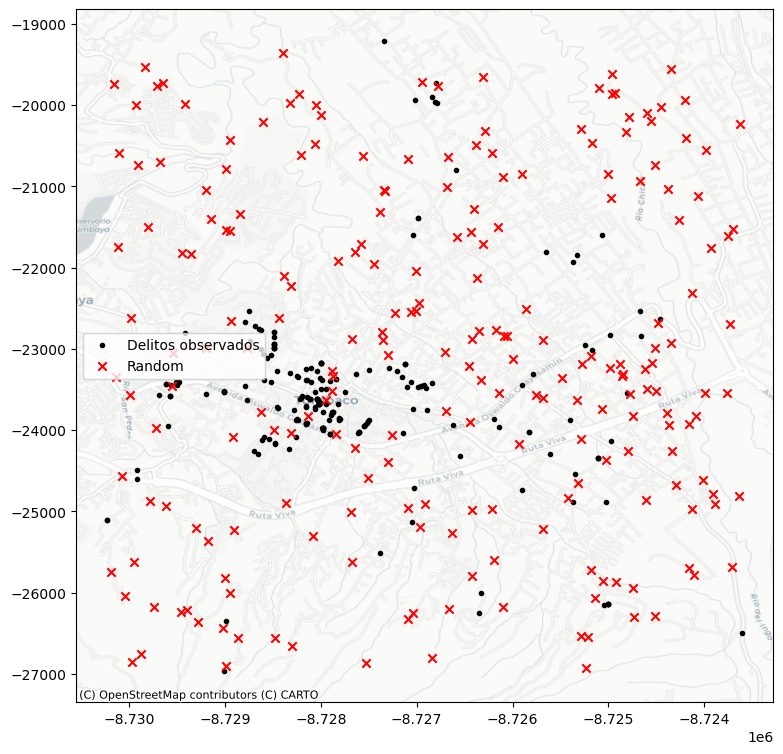

In [19]:
f, ax = plt.subplots(1, figsize=(9, 9))
plt.scatter(
    *coordinates.T,
    color="k",
    marker=".",
    label="Delitos observados"
)
plt.scatter(*random_pattern.T, color="r", marker="x", label="Random")
ctx.add_basemap(
    ax,
    # crs="EPSG:4326", 
    source=ctx.providers.CartoDB.Positron
)
ax.legend(ncol=1, loc="center left")
plt.show()


Como se observa en la simulación básica, el generador de patrones aleatorios —por defecto— utiliza el **rectángulo envolvente (bounding box)** del patrón original como área de referencia. Sin embargo, este enfoque puede ser poco representativo si el patrón observado está concentrado en un espacio **más restringido o con una forma compleja**.


In [20]:
random_pattern_ashape = random.poisson(
    alpha_shape, size=len(coordinates)
)

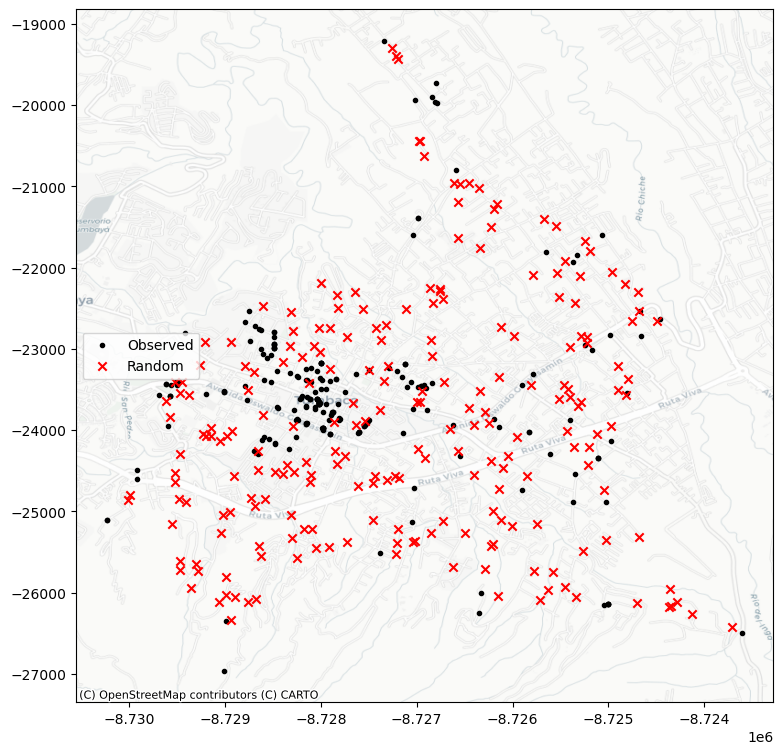

In [21]:
f, ax = plt.subplots(1, figsize=(9, 9))
plt.scatter(*coordinates.T, color="k", marker=".", label="Observed")
plt.scatter(
    *random_pattern_ashape.T, color="r", marker="x", label="Random"
)
ctx.add_basemap(
    ax, 
    # crs="EPSG:4326", 
    source=ctx.providers.CartoDB.Positron
)
ax.legend(ncol=1, loc="center left")
plt.show()

## Estadísticos de Cuadrantes (Quadrat Statistics)

Los **estadísticos de cuadrantes** son una técnica clásica para analizar la **distribución espacial** de eventos, mediante el conteo de puntos que caen dentro de **celdas regulares** (cuadrantes) que dividen el área de estudio.

**¿Cómo funciona?**

- El área total se divide en una **cuadrícula de celdas iguales**.
- Se cuenta cuántos eventos caen dentro de cada celda.
- Se analiza si los conteos están **uniformemente distribuidos** o si se concentran en unas pocas celdas.

**Objetivo**

La idea principal es detectar si los puntos están:

- **Distribuidos homogéneamente** (como en un proceso aleatorio), o
- **Agrupados en ciertas zonas** (indicando clustering o patrones no aleatorios).

**Fundamento estadístico**

- Este enfoque se basa en una **prueba estadística** similar a la utilizada en el análisis de **tablas de contingencia** (por ejemplo, la prueba de **Chi-cuadrado**).
- Compara la distribución observada de conteos con una distribución esperada bajo el supuesto de aleatoriedad espacial.

**Visualización en Python**

El paquete `pointpats` permite aplicar este análisis y visualizarlo mediante el método `QStatistic.plot()`, que genera una figura (como la Figura 11) mostrando:

- La **cuadrícula utilizada** para el conteo.
- El **patrón de puntos subyacente**.

Esto permite observar visualmente **qué celdas concentran más eventos** y si existe una distribución equitativa.

**Aplicaciones**

En análisis urbanos (como delitos en Quito), este método es útil para:

- Detectar **zonas críticas** donde se acumulan eventos.
- Evaluar si los incidentes están **aleatoriamente distribuidos** o siguen un patrón estructurado.
- Justificar la **intervención focalizada** en ciertos sectores del espacio urbano.

En resumen, los cuadrantes ofrecen una forma intuitiva y estadísticamente sólida de explorar **la regularidad o agrupamiento** en patrones espaciales.


<Axes: title={'center': 'Quadrat Count'}>

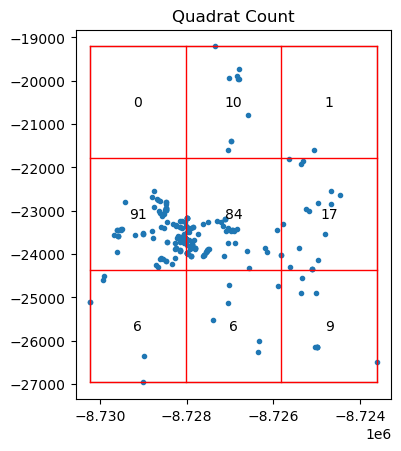

In [22]:
qstat = QStatistic(coordinates)
qstat.plot()

## Interpretación del Resultado: Distribución No Uniforme

En este ejemplo, al aplicar una **cuadrícula de 3x3** sobre el patrón de puntos (como fotografías geolocalizadas en Flickr), observamos que:

- Las **celdas periféricas** tienen muchas menos observaciones.

**¿Qué implica esto?**

Esta distribución indica un **agrupamiento evidente** en el centro del área analizada, lo que **rompe con la suposición de uniformidad** que se esperaría bajo un proceso espacial completamente aleatorio.

**Prueba de chi-cuadrado**

La prueba de **Chi-cuadrado** compara los conteos observados en cada celda con los conteos esperados bajo el supuesto de una distribución uniforme. En este caso:

- La gran diferencia entre el conteo de la celda central y las demás genera un **valor del estadístico chi-cuadrado alto**.
- Esto se traduce en un **p-valor muy bajo**, lo que sugiere que la **distribución observada no es aleatoria**.

**Conclusión**

El resultado es **estadísticamente significativo**, lo que implica que hay evidencia suficiente para rechazar la hipótesis nula de uniformidad espacial. En otras palabras, **los puntos están agrupados** en lugar de distribuidos de forma homogénea.

Este tipo de análisis es clave para identificar **zonas calientes** o **puntos críticos** en estudios espaciales, como los relacionados con delitos, servicios urbanos o comportamiento humano en el territorio.


In [23]:
qstat.chi2_pvalue

np.float64(1.8598066523883764e-84)

<Axes: title={'center': 'Quadrat Count'}>

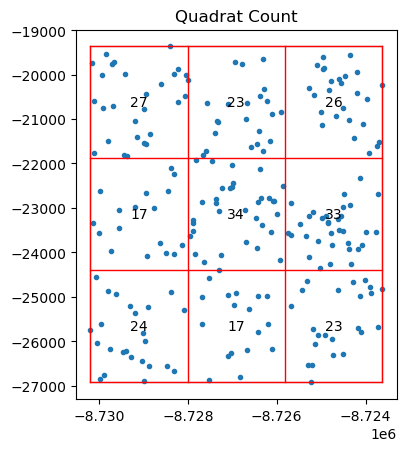

In [24]:
qstat_null = QStatistic(random_pattern)
qstat_null.plot()



En contraste con el patrón observado (agrupado), cuando generamos un patrón a partir de un **proceso de puntos completamente aleatorio** (como el **proceso de Poisson**), la distribución de eventos en la cuadrícula es **mucho más uniforme**.


Tiene un pvalor alto y no significativo

In [25]:
qstat_null.chi2_pvalue

np.float64(0.1735988962616851)



Si bien los **estadísticos de cuadrantes** son una herramienta poderosa para detectar agrupamiento espacial, es importante tener en cuenta sus **limitaciones** y el contexto de aplicación.

**Problema: Superposición regular sobre un patrón irregular**

El método se basa en superponer una **cuadrícula regular** (rejilla) sobre el área de estudio, pero:

- Si el **patrón de puntos tiene una forma irregular** (como un **alpha shape**),
- Y la cuadrícula no se ajusta a esa forma (es decir, incluye áreas vacías o exteriores),

Entonces, los resultados pueden ser **engañosos**.

**Posible consecuencia**

- Un **patrón aleatorio e irregular** (simulado dentro de un alpha shape) puede ser clasificado erróneamente como **agrupado** si las celdas caen en áreas sin puntos simplemente por la forma del polígono.
- Esto puede generar un **estadístico chi-cuadrado elevado** y un **p-valor bajo**, sugiriendo falsamente agrupamiento.

**Ejemplo en la Figura**

En la **Figura**, se observa un patrón aleatorio generado dentro de un **alpha shape**. Al aplicar una cuadrícula regular por fuera, algunas celdas incluyen **zonas sin puntos** simplemente porque caen fuera del área válida, distorsionando así los conteos y el análisis.

### Recomendación

Para evitar interpretaciones erróneas:

- Asegúrate de que la cuadrícula se **ajuste adecuadamente al área real del patrón**.
- Considera usar métodos alternativos o complementarios (como **Ripley’s K**, KDE, o alpha shapes) para validar los resultados.
- Siempre **verifica visualmente** el ajuste entre la cuadrícula y el área de estudio.

En resumen, el análisis por cuadrantes es útil, pero debe aplicarse con cuidado cuando se trabaja con **patrones espaciales de extensión irregular**.


<Axes: title={'center': 'Quadrat Count'}>

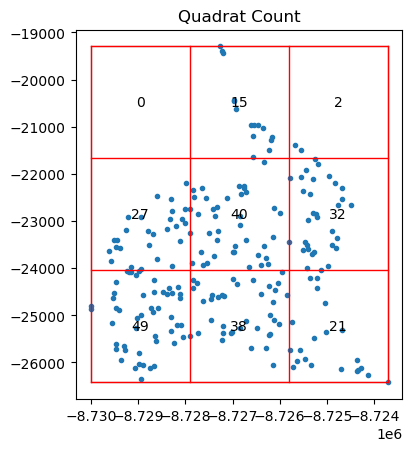

In [26]:
qstat_null_ashape = QStatistic(random_pattern_ashape)
qstat_null_ashape.plot()

La prueba de cuadrantes determina que esto no es aleatorio desde el punto de vista estadístico, mientras que nuestro proceso de simulación garantizó que, dentro del área de estudio definida, el patrón corresponde a un proceso completamente aleatorio en el espacio.

In [27]:
qstat_null_ashape.chi2_pvalue

np.float64(1.7209978285810554e-16)

**Limitaciones de los Estadísticos de Cuadrantes**

Los **estadísticos de cuadrantes** pueden ser problemáticos cuando se aplican a áreas de estudio **irregulares**, ya que podrían **identificar falsamente agrupamiento**.

Una forma más adecuada de interpretarlos es considerarlos como una prueba que evalúa tanto la **uniformidad de los puntos** como la **forma del área analizada**, dentro de una **rejilla regular**.

**Conclusión**

- En algunos casos, esta técnica es **útil y válida**.
- En otros, debe aplicarse **con precaución** para evitar conclusiones erróneas sobre la existencia de agrupamiento.


### El Alfabeto de Funciones de Ripley

El segundo conjunto de estadísticas espaciales se enfoca en analizar dos aspectos clave en los patrones de puntos:

1. Las **distancias al vecino más cercano**, y  
2. Los **“vacíos”** o huecos dentro del patrón.

Estas técnicas derivan del trabajo seminal de **Ripley (1991)**, cuyo objetivo fue **caracterizar el grado de agrupamiento o co-ubicación** en patrones espaciales, evaluando cómo cambian estas relaciones al **aumentar progresivamente la distancia de análisis** desde cada punto.

#### Función G de Ripley: Vecinos más cercanos

La primera función de este conjunto es la **función G**, que resume la distribución de las **distancias al vecino más cercano** para cada punto del patrón.

- Para cada punto, se calcula la distancia al **punto más próximo**.
- Luego, se construye una función acumulativa que indica la **proporción de puntos que tienen un vecino a una distancia menor o igual a un valor dado**.

### Visualización

En la **Figura **, esta lógica se representa de la siguiente manera:

- Los **puntos rojos** son una sección del patrón original.
- Las **flechas negras** muestran la conexión de cada punto con su **vecino más cercano**.
- Algunos puntos son **vecinos mutuos** (hay flechas en ambas direcciones), mientras que otros no.

### Interpretación

- Si el patrón es **agrupado**, muchos puntos tendrán vecinos muy cercanos → la función G crecerá rápidamente.
- Si es **disperso o uniforme**, las distancias serán mayores → la función crecerá más lentamente.
- Comparar la función G observada con la esperada bajo un **patrón aleatorio** (como un proceso de Poisson) permite detectar **agrupamiento o repulsión**.

Estas herramientas permiten un análisis más detallado de la **estructura interna** del patrón, más allá de la simple ubicación o conteo de eventos.


Para hacer esto con el paquete `pointpats`, podemos usar la función `g_test`, la cual calcula tanto la función G para los datos empíricos como las réplicas hipotéticas bajo un proceso completamente aleatorio en el espacio.

In [28]:

g_test = distance_statistics.g_test(
    coordinates, support=40, keep_simulations=True
)



Cuando analizamos la distribución de **distancias al vecino más cercano**, podemos clasificar el patrón de puntos de la siguiente manera:

- Un patrón **agrupado (clustered)** tendrá **más puntos cercanos entre sí** → la función **G** crecerá **rápidamente**.
- Un patrón **disperso** tendrá puntos **más alejados** → la función G crecerá **lentamente**.
- Un patrón **aleatorio** tendrá un crecimiento **intermedio**, sin tendencia clara.

**Visualización (Figura)**

En la **Figura**, se muestra cómo se interpreta gráficamente esta función:

- El eje horizontal representa la **distancia al punto más cercano** (d).
- El eje vertical representa la **proporción acumulada** de puntos que tienen un vecino a una distancia ≤ d.
- La **línea roja** muestra la **función G empírica** calculada a partir de los datos observados (por ejemplo, fotos de un usuario de Flickr).
- Las **líneas azules** representan múltiples simulaciones bajo un **patrón completamente aleatorio** (Poisson):
  - La línea azul clara es el **promedio** de esas simulaciones.
  - La banda azul oscura/negra indica el **intervalo de confianza del 95%** de los resultados simulados.

**Conclusión del ejemplo**

En este caso, la **línea roja asciende más rápidamente** que las simulaciones aleatorias, lo que indica que:

- Los puntos observados (fotografías) están **más cerca entre sí** de lo que cabría esperar por azar.
- Por lo tanto, el patrón es **agrupado**, mostrando **evidencia clara de clustering**.

Este análisis es útil para confirmar, con base estadística, que un patrón espacial tiene **estructura interna no aleatoria**, lo que puede tener implicaciones importantes para estudios de comportamiento humano, movilidad, o fenómenos urbanos como el crimen.


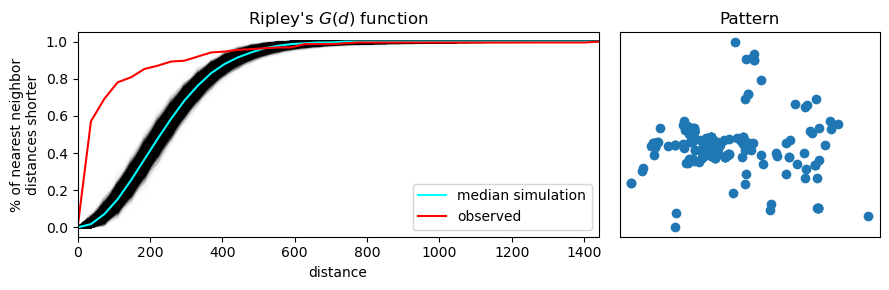

In [29]:
f, ax = plt.subplots(
    1, 2, figsize=(9, 3), gridspec_kw=dict(width_ratios=(6, 3))
)
# plot all the simulations with very fine lines
ax[0].plot(
    g_test.support, g_test.simulations.T, color="k", alpha=0.01
)
# and show the average of simulations
ax[0].plot(
    g_test.support,
    np.median(g_test.simulations, axis=0),
    color="cyan",
    label="median simulation",
)


# and the observed pattern's G function
ax[0].plot(
    g_test.support, g_test.statistic, label="observed", color="red"
)

# clean up labels and axes
ax[0].set_xlabel("distance")
ax[0].set_ylabel("% of nearest neighbor\ndistances shorter")
ax[0].legend()
ax[0].set_xlim(0, np.max(g_test.support))
ax[0].set_title(r"Ripley's $G(d)$ function")

# plot the pattern itself on the next frame
ax[1].scatter(*coordinates.T)

# and clean up labels and axes there, too
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].set_title("Pattern")
f.tight_layout()
plt.show()


La segunda función que introducimos es la **función F de Ripley**, también conocida como la **función del espacio vacío**. A diferencia de la función G, que mide las distancias **entre puntos del patrón**, la función F analiza la distancia **desde ubicaciones aleatorias en el espacio hacia el punto más cercano del patrón**.

**¿Qué mide la función F?**

- Evalúa la **proximidad de puntos del patrón a ubicaciones aleatorias en el espacio**.
- A medida que se incrementa la distancia \( d \), la función acumula el **porcentaje de esos puntos aleatorios** que caen a una distancia menor o igual a \( d \) de algún punto del patrón observado.
- Por eso se le llama la **función del espacio vacío**: mide cuánto “vacío” hay en el patrón.

**Interpretación**

- Si el patrón tiene **grandes vacíos o huecos**, la función F crecerá **lentamente** → indica **agrupamiento**.
- Si el patrón está **muy disperso**, la función F crecerá **rápidamente**, ya que es más probable que cualquier punto aleatorio esté cerca de un evento.

**Análisis gráfico**

Al igual que con la función G, se compara la función F del patrón observado con:

- Una **media** de múltiples simulaciones aleatorias (línea azul clara).
- Un **intervalo de confianza del 95%** basado en simulaciones (banda azul oscuro o negra).

Si la **función F empírica (roja)** crece **más lentamente** que la banda de simulaciones aleatorias, esto indica que:

- En el patrón hay **mayor cantidad de espacio vacío** del que esperaríamos por azar.
- El patrón es, por tanto, **agrupado (clustered)**.

**Cálculo en Python**

La función F se implementa en `pointpats` mediante la función `f_test()`, y su análisis gráfico es análogo al de la función G.

**Conclusión**

La función F ofrece una perspectiva complementaria sobre la **estructura espacial** del patrón, ayudando a detectar **áreas sin eventos** (gaps) y a confirmar la **presencia de agrupamiento** cuando los puntos están concentrados en ciertas regiones del espacio.


In [30]:

f_test = distance_statistics.f_test(
    coordinates, support=40, keep_simulations=True
)

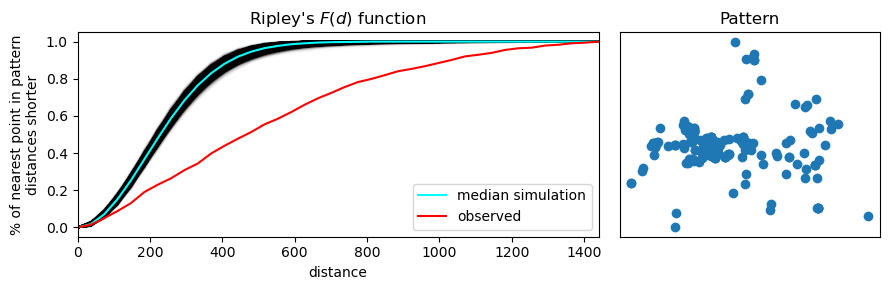

In [31]:
f, ax = plt.subplots(
    1, 2, figsize=(9, 3), gridspec_kw=dict(width_ratios=(6, 3))
)

# plot all the simulations with very fine lines
ax[0].plot(
    f_test.support, f_test.simulations.T, color="k", alpha=0.01
)
# and show the average of simulations
ax[0].plot(
    f_test.support,
    np.median(f_test.simulations, axis=0),
    color="cyan",
    label="median simulation",
)


# and the observed pattern's F function
ax[0].plot(
    f_test.support, f_test.statistic, label="observed", color="red"
)

# clean up labels and axes
ax[0].set_xlabel("distance")
ax[0].set_ylabel("% of nearest point in pattern\ndistances shorter")
ax[0].legend()
ax[0].set_xlim(0, np.max(f_test.support))
ax[0].set_title(r"Ripley's $F(d)$ function")

# plot the pattern itself on the next frame
ax[1].scatter(*coordinates.T)

# and clean up labels and axes there, too
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].set_title("Pattern")
f.tight_layout()
plt.show()
